<a href="https://qworld.net" target="_blank" align="left"><img src="../../qworld/images/header.jpg"  align="left"></a>
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\I}{ \mymatrix{rr}{1 & 0 \\ 0 & 1}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\greenbit}[1] {\mathbf{{\color{green}#1}}} $
$ \newcommand{\bluebit}[1] {\mathbf{{\color{blue}#1}}} $
$ \newcommand{\redbit}[1] {\mathbf{{\color{red}#1}}} $
$ \newcommand{\brownbit}[1] {\mathbf{{\color{brown}#1}}} $
$ \newcommand{\blackbit}[1] {\mathbf{{\color{black}#1}}} $

# Solutions - Ansatz Families and Expressivity

_Prepared by Claudia Zendejas-Morales_

This notebook contains complete solutions for the embedded tasks in notebook `2.3`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit.circuit.library import real_amplitudes, efficient_su2, n_local, zz_feature_map
from qiskit.quantum_info import Statevector, state_fidelity

import pennylane as qml


<a id="task1-solution"></a>

## Task 1 (coding): One complete solution

We implement a custom two-local ansatz in PennyLane and compare how repetitions and connectivity affect parameter count and circuit cost on five wires.


(1, 'linear') {'num_parameters': 10, 'depth': 6, 'ops': {'RY': 10, 'CNOT': 4}, 'weights_shape': (2, 5)}
(1, 'circular') {'num_parameters': 10, 'depth': 7, 'ops': {'RY': 10, 'CNOT': 5}, 'weights_shape': (2, 5)}
(1, 'full') {'num_parameters': 10, 'depth': 9, 'ops': {'RY': 10, 'CNOT': 10}, 'weights_shape': (2, 5)}
(3, 'linear') {'num_parameters': 20, 'depth': 12, 'ops': {'RY': 20, 'CNOT': 12}, 'weights_shape': (4, 5)}
(3, 'circular') {'num_parameters': 20, 'depth': 19, 'ops': {'RY': 20, 'CNOT': 15}, 'weights_shape': (4, 5)}
(3, 'full') {'num_parameters': 20, 'depth': 21, 'ops': {'RY': 20, 'CNOT': 30}, 'weights_shape': (4, 5)}


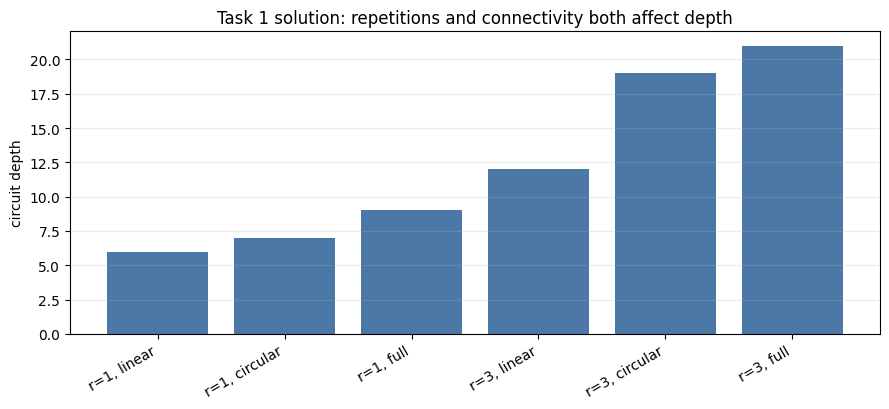

0: ──RY(0.00)─╭●──────────╭X──RY(0.00)─╭●──────────╭X──RY(0.00)─╭●──────────╭X──RY(0.00)─┤ ╭Probs
1: ──RY(0.00)─╰X─╭●───────│───RY(0.00)─╰X─╭●───────│───RY(0.00)─╰X─╭●───────│───RY(0.00)─┤ ├Probs
2: ──RY(0.00)────╰X─╭●────│───RY(0.00)────╰X─╭●────│───RY(0.00)────╰X─╭●────│───RY(0.00)─┤ ├Probs
3: ──RY(0.00)───────╰X─╭●─│───RY(0.00)───────╰X─╭●─│───RY(0.00)───────╰X─╭●─│───RY(0.00)─┤ ├Probs
4: ──RY(0.00)──────────╰X─╰●──RY(0.00)──────────╰X─╰●──RY(0.00)──────────╰X─╰●──RY(0.00)─┤ ╰Probs

Conceptual answers:
- Increasing reps increases the parameter count because each extra repetition adds one more RY layer on every wire.
- Changing connectivity can increase circuit cost even when the parameter count stays fixed, because denser entanglement patterns add more CNOT gates and usually more depth.


In [2]:
def entangling_layer(pattern, wires):
    if pattern == "linear":
        for w in range(len(wires) - 1):
            qml.CNOT(wires=[wires[w], wires[w + 1]])
    elif pattern == "circular":
        for w in range(len(wires) - 1):
            qml.CNOT(wires=[wires[w], wires[w + 1]])
        qml.CNOT(wires=[wires[-1], wires[0]])
    elif pattern == "full":
        for control in range(len(wires)):
            for target in range(control + 1, len(wires)):
                qml.CNOT(wires=[wires[control], wires[target]])
    else:
        raise ValueError(f"Unknown pattern: {pattern}")


def two_local_ansatz(weights, pattern, wires):
    n_layers_plus_last, n_wires = weights.shape
    if n_wires != len(wires):
        raise ValueError("weights shape does not match the number of wires")

    for rep in range(n_layers_plus_last - 1):
        for q, wire in enumerate(wires):
            qml.RY(weights[rep, q], wires=wire)
        entangling_layer(pattern, wires)

    for q, wire in enumerate(wires):
        qml.RY(weights[-1, q], wires=wire)


wires = list(range(5))
dev = qml.device("default.qubit", wires=len(wires))

@qml.qnode(dev)
def two_local_qnode(weights, pattern):
    two_local_ansatz(weights, pattern, wires)
    return qml.probs(wires=wires)


def summarize_two_local(reps, pattern, n_wires=5):
    weights = np.zeros((reps + 1, n_wires))
    specs = qml.specs(two_local_qnode)(weights, pattern)
    resources = specs["resources"]
    op_counts = {name: int(count) for name, count in resources.gate_types.items()}
    return {
        "num_parameters": int(weights.size),
        "depth": int(resources.depth),
        "ops": op_counts,
        "weights_shape": tuple(weights.shape),
    }


reps_list = [1, 3]
entanglement_patterns = ["linear", "circular", "full"]
summary = {}

for reps in reps_list:
    for pattern in entanglement_patterns:
        summary[(reps, pattern)] = summarize_two_local(reps, pattern)

for key, value in summary.items():
    print(key, value)

labels = [f"r={reps}, {pattern}" for reps in reps_list for pattern in entanglement_patterns]
depths = [summary[(reps, pattern)]["depth"] for reps in reps_list for pattern in entanglement_patterns]

plt.figure(figsize=(9, 4.2))
plt.bar(labels, depths, color="#4c78a8")
plt.xticks(rotation=30, ha="right")
plt.ylabel("circuit depth")
plt.title("Task 1 solution: repetitions and connectivity both affect depth")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

example_weights = np.zeros((4, 5))
print(qml.draw(two_local_qnode)(example_weights, "circular"))

print("\nConceptual answers:")
print("- Increasing reps increases the parameter count because each extra repetition adds one more RY layer on every wire.")
print("- Changing connectivity can increase circuit cost even when the parameter count stays fixed, because denser entanglement patterns add more CNOT gates and usually more depth.")


The parameter count increases with `reps` because each extra repetition adds another trainable rotation layer. By contrast, changing the entanglement pattern can increase depth and two-qubit gate count even when the parameter count stays fixed, because denser connectivity requires more entangling operations.

<a id="task2-solution"></a>

## Task 2 (optional, coding): One complete solution

We use PennyLane's built-in `qml.BasicEntanglerLayers` template with `rotation=qml.RY` to compare the cases `reps=1` and `reps=3`.


In [3]:
n_wires = 5
reps_list = [1, 3]
wires = list(range(n_wires))
dev_basic = qml.device("default.qubit", wires=n_wires)

@qml.qnode(dev_basic)
def basic_entangler_qnode(weights):
    qml.BasicEntanglerLayers(weights=weights, wires=wires, rotation=qml.RY)
    return qml.probs(wires=wires)

def summarize_basic_entangler(reps, n_wires=5):
    shape = qml.BasicEntanglerLayers.shape(n_layers=reps, n_wires=n_wires)
    weights = np.linspace(0.1, 1.0, num=np.prod(shape)).reshape(shape)
    specs = qml.specs(basic_entangler_qnode)(weights)
    resources = specs["resources"]
    op_counts = {name: int(count) for name, count in resources.gate_types.items()}
    return {
        "shape": tuple(shape),
        "num_parameters": int(np.prod(shape)),
        "depth": int(resources.depth),
        "ops": op_counts,
        "weights": weights,
    }

summary = {reps: summarize_basic_entangler(reps, n_wires=n_wires) for reps in reps_list}

for reps in reps_list:
    print(f"reps={reps}")
    print("  weight shape:", summary[reps]["shape"])
    print("  num parameters:", summary[reps]["num_parameters"])
    print("  depth:", summary[reps]["depth"])
    print("  ops:", summary[reps]["ops"])

print("\nCircuit for reps=1 (template view):\n")
print(qml.draw(basic_entangler_qnode)(summary[1]["weights"]))
print("\nCircuit for reps=1 (expanded to device-level operations):\n")
print(qml.draw(basic_entangler_qnode, level="device")(summary[1]["weights"]))

print("\nCircuit for reps=3 (template view):\n")
print(qml.draw(basic_entangler_qnode)(summary[3]["weights"]))
print("\nCircuit for reps=3 (expanded to device-level operations):\n")
print(qml.draw(basic_entangler_qnode, level="device")(summary[3]["weights"]))


reps=1
  weight shape: (1, 5)
  num parameters: 5
  depth: 1
  ops: {'BasicEntanglerLayers': 1}
reps=3
  weight shape: (3, 5)
  num parameters: 15
  depth: 1
  ops: {'BasicEntanglerLayers': 1}

Circuit for reps=1 (template view):

0: ─╭BasicEntanglerLayers(M0)─┤ ╭Probs
1: ─├BasicEntanglerLayers(M0)─┤ ├Probs
2: ─├BasicEntanglerLayers(M0)─┤ ├Probs
3: ─├BasicEntanglerLayers(M0)─┤ ├Probs
4: ─╰BasicEntanglerLayers(M0)─┤ ╰Probs

M0 = 
[[0.1   0.325 0.55  0.775 1.   ]]

Circuit for reps=1 (expanded to device-level operations):

0: ──RY(0.10)─╭●──────────╭X─┤ ╭Probs
1: ──RY(0.33)─╰X─╭●───────│──┤ ├Probs
2: ──RY(0.55)────╰X─╭●────│──┤ ├Probs
3: ──RY(0.78)───────╰X─╭●─│──┤ ├Probs
4: ──RY(1.00)──────────╰X─╰●─┤ ╰Probs

Circuit for reps=3 (template view):

0: ─╭BasicEntanglerLayers(M0)─┤ ╭Probs
1: ─├BasicEntanglerLayers(M0)─┤ ├Probs
2: ─├BasicEntanglerLayers(M0)─┤ ├Probs
3: ─├BasicEntanglerLayers(M0)─┤ ├Probs
4: ─╰BasicEntanglerLayers(M0)─┤ ╰Probs

M0 = 
[[0.1        0.16428571 0.22857143 0.292857

This template is only approximately analogous to Qiskit's `real_amplitudes`. The similarity is that both use one-parameter single-qubit rotations together with repeated CNOT entangling layers. The difference is that `qml.BasicEntanglerLayers` comes with a built-in closed-chain entangling pattern, while Qiskit's `real_amplitudes` exposes several connectivity choices such as `linear`, `circular`, and `full`. So `qml.BasicEntanglerLayers` is a natural built-in PennyLane reference for this family, but not a strict drop-in replacement for every `real_amplitudes` option. When drawing the circuit, `qml.draw(...)` shows the template in compact form, while `qml.draw(..., level="device")` expands it to the lower-level operations seen by the device.

<a id="task3-solution"></a>

## Task 3 (coding): One complete solution

Qiskit does not provide a template called `StronglyEntanglingLayers`, but `n_local` is flexible enough to build a close analogue with the same local `R_z R_y R_z` structure and a layer-wise custom entanglement map.


ranges_a: [1, 1, 1]


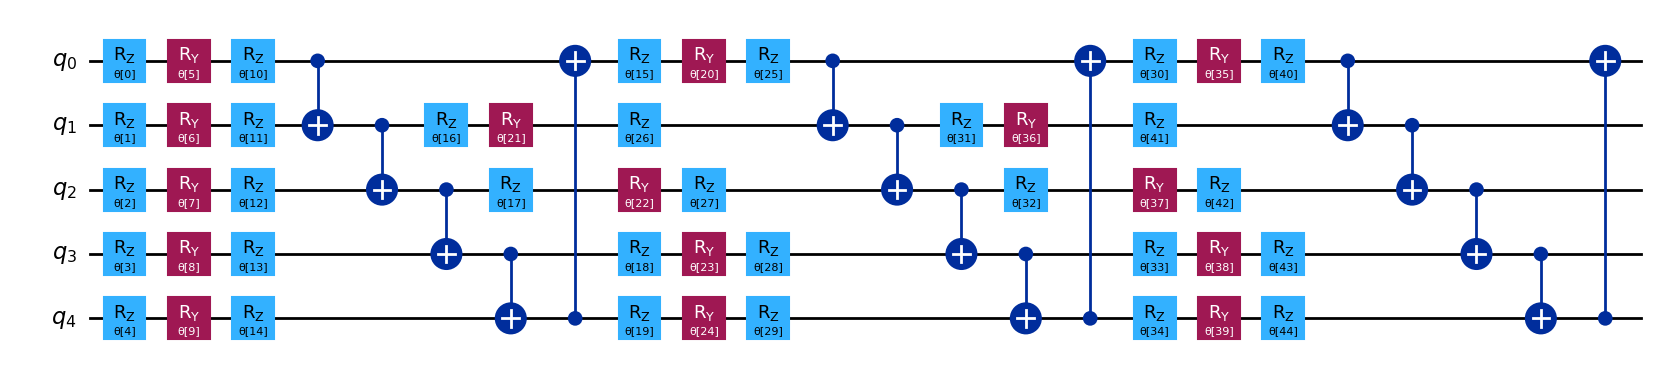


ranges_b: [1, 2, 1]


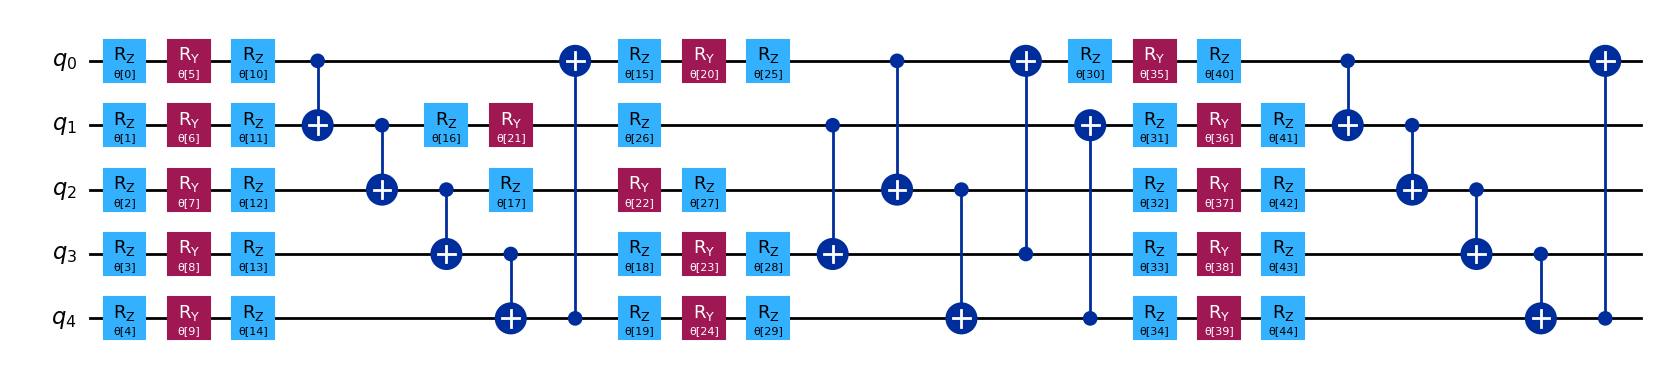


ranges_a
  num parameters: 45
  depth: 24
  ops: {'p': 30, 'r': 15, 'cx': 15}
ranges_b
  num parameters: 45
  depth: 22
  ops: {'p': 30, 'r': 15, 'cx': 15}


In [4]:
n_wires = 5
ranges_a = [1, 1, 1]
ranges_b = [1, 2, 1]

def range_entanglement(n_wires, r):
    return [[q, (q + r) % n_wires] for q in range(n_wires)]

def strongly_entangling_style_qiskit(n_wires, ranges):
    def entanglement(layer_idx):
        return range_entanglement(n_wires, ranges[layer_idx])

    return n_local(
        num_qubits=n_wires,
        rotation_blocks=["rz", "ry", "rz"],
        entanglement_blocks="cx",
        entanglement=entanglement,
        reps=len(ranges),
        skip_final_rotation_layer=True,
    )

def summarize_circuit(circuit):
    decomposed = circuit.decompose()
    return {
        "num_parameters": circuit.num_parameters,
        "depth": decomposed.depth(),
        "ops": dict(decomposed.count_ops()),
    }

circuit_a = strongly_entangling_style_qiskit(n_wires, ranges_a)
circuit_b = strongly_entangling_style_qiskit(n_wires, ranges_b)

print("ranges_a:", ranges_a)
display(circuit_a.draw("mpl"))
print()
print("ranges_b:", ranges_b)
display(circuit_b.draw("mpl"))
print()
for name, circuit in [("ranges_a", circuit_a), ("ranges_b", circuit_b)]:
    info = summarize_circuit(circuit)
    print(name)
    print("  num parameters:", info["num_parameters"])
    print("  depth:", info["depth"])
    print("  ops:", info["ops"])


Both circuits have the same number of trainable parameters because they use the same number of qubits, the same local `R_z R_y R_z` block, and the same number of repetitions. What changes is only the entanglement map of the middle layer. In `ranges_a = [1, 1, 1]`, every layer uses nearest-neighbor-style cyclic couplings. In `ranges_b = [1, 2, 1]`, the middle layer couples qubits at a larger cyclic distance, so the entangling structure becomes less local without changing the parameter budget.


<a id="task4-solution"></a>

## Task 4 (coding): One complete solution

We compare two versions of `qml.BasicEntanglerLayers` with `reps=1` and `reps=3` on the same fixed encoded input, using `qml.math.fidelity_statevector` as the state-similarity heuristic.


reps=1
  weight shape: (1, 3)
  num parameters: 3
  depth: 2
  mean pairwise fidelity: 0.12487286119984443
reps=3
  weight shape: (3, 3)
  num parameters: 9
  depth: 2
  mean pairwise fidelity: 0.14113685513373017


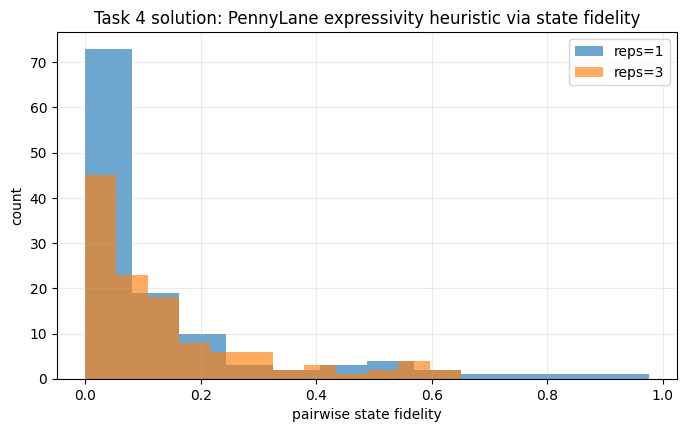

In [5]:
sample = np.array([0.30, 0.80, 1.10])
n_wires = 3
dev_expr = qml.device("default.qubit", wires=n_wires)

@qml.qnode(dev_expr)
def embedded_basic_entangler(sample, weights):
    qml.AngleEmbedding(sample, wires=range(n_wires), rotation="Y")
    qml.BasicEntanglerLayers(weights=weights, wires=range(n_wires), rotation=qml.RY)
    return qml.state()

def sampled_fidelities_pennylane(sample, reps, n_samples=16, seed=11):
    rng = np.random.default_rng(seed)
    shape = qml.BasicEntanglerLayers.shape(n_layers=reps, n_wires=n_wires)
    states = []
    for _ in range(n_samples):
        weights = rng.uniform(0.0, 2 * np.pi, size=shape)
        states.append(embedded_basic_entangler(sample, weights))

    fidelities = []
    for a in range(len(states)):
        for b in range(a + 1, len(states)):
            fidelities.append(qml.math.fidelity_statevector(states[a], states[b]))
    return np.array(fidelities), shape

results = {}
for reps in [1, 3]:
    fids, shape = sampled_fidelities_pennylane(sample, reps)
    zero_weights = np.zeros(shape)
    specs = qml.specs(embedded_basic_entangler)(sample, zero_weights)
    results[reps] = {
        "fids": fids,
        "shape": tuple(shape),
        "num_parameters": int(np.prod(shape)),
        "depth": int(specs["resources"].depth),
    }

for reps in [1, 3]:
    print(f"reps={reps}")
    print("  weight shape:", results[reps]["shape"])
    print("  num parameters:", results[reps]["num_parameters"])
    print("  depth:", results[reps]["depth"])
    print("  mean pairwise fidelity:", float(np.mean(results[reps]["fids"])))

plt.figure(figsize=(8, 4.5))
plt.hist(results[1]["fids"], bins=12, alpha=0.65, label="reps=1")
plt.hist(results[3]["fids"], bins=12, alpha=0.65, label="reps=3")
plt.xlabel("pairwise state fidelity")
plt.ylabel("count")
plt.title("Task 4 solution: PennyLane expressivity heuristic via state fidelity")
plt.grid(alpha=0.25)
plt.legend()
plt.show()


A lower mean pairwise fidelity suggests that the deeper `reps=3` family spreads sampled states more broadly for the same encoded input, which is consistent with greater expressivity under this heuristic. The extra flexibility is not free: the deeper ansatz also has a larger weight tensor and greater circuit depth, so the gain in representational reach comes with added circuit cost.


<a id="task5-solution"></a>

## Task 5 (design): One complete solution

**Scenario A.** A reasonable choice is a shallow two-local or hardware-efficient ansatz with nearest-neighbor entanglement. The device already has local connectivity and non-negligible two-qubit noise, so the circuit should respect that structure instead of forcing denser interactions. A shallow nearest-neighbor design controls depth and keeps calibration demands moderate. The key priority here is trainability under hardware noise, not maximal expressivity.

**Scenario B.** A reasonable choice is a strongly entangling family or a richer hardware-efficient family on the simulator. Since hardware noise is not the bottleneck, the main question is whether the ansatz can represent nonlocal correlations flexibly enough for experimentation. A larger parameter count is acceptable in this setting, so deeper or more globally entangling patterns are easier to justify. The important caution is still optimization: more expressive does not mean automatically easier to train.

**Scenario C.** A reasonable choice is a hardware-efficient ansatz tailored to the device-specific structure. The prompt explicitly says that non-native compilation overhead is expensive, so respecting the hardware graph should be part of the ansatz design from the start. This is exactly the setting where hardware-efficient thinking is strongest. The ansatz should prioritize native gates and connectivity rather than abstract circuit symmetry.

**Scenario D.** A reasonable choice is to simplify the circuit before adding more layers. The observed behavior suggests that extra depth is no longer producing better validation performance, even if random-state heuristics still indicate high expressivity. That is a warning that trainability or generalization may now be the bottleneck rather than raw representational capacity. Reducing depth or parameters is often the better next move in that regime.